# House Price Prediction — Model Notebook

#اميره محمد عبد الحميد محمد 


#نورهان طه محمد مصطفي 


#شهد السيد محمد فتحي 


## 1. Load & Inspect

In [1]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", 50)

df = pd.read_csv("data/house_prices.csv")
df.shape

(187531, 21)

In [3]:
df.head()

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,Furnishing,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,Unfurnished,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,Semi-Furnished,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,Unfurnished,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,Unfurnished,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,Unfurnished,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  str    
 2   Description        184508 non-null  str    
 3   Amount(in rupees)  187531 non-null  str    
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  str    
 6   Carpet Area        106858 non-null  str    
 7   Status             186916 non-null  str    
 8   Floor              180454 non-null  str    
 9   Transaction        187448 non-null  str    
 10  Furnishing         184634 non-null  str    
 11  facing             117298 non-null  str    
 12  overlooking        106095 non-null  str    
 13  Society            77853 non-null   str    
 14  Bathroom           186703 non-null  str    
 15  Balcony            138596 non-null  str    
 16  Car Parking  

In [5]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Index,187531.0,NaN,NaN,NaN,93765.0,54135.681003,0.0,46882.5,93765.0,140647.5,187530.0
Title,187531,32446,2 BHK Ready to Occupy Flat for sale in Divyasr...,2106,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,184508,65634,Multistorey apartment is available for sale. I...,2732,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Amount(in rupees),187531,1561,Call for Price,9684,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price (in rupees),169866.0,NaN,NaN,NaN,7583.771885,27241.705819,0.0,4297.0,6034.0,9450.0,6700000.0
location,187531,81,new-delhi,27599,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Carpet Area,106858,2758,1000 sqft,5285,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Status,186916,1,Ready to Move,186916,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Floor,180454,947,2 out of 4,12433,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transaction,187448,4,Resale,144172,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
missing = df.isna().mean().sort_values(ascending=False)
missing

Plot Area            1.000000
Dimensions           1.000000
Society              0.584853
Super Area           0.574225
Car Parking          0.551146
overlooking          0.434254
Carpet Area          0.430185
facing               0.374514
Ownership            0.349366
Balcony              0.260944
Price (in rupees)    0.094198
Floor                0.037738
Description          0.016120
Furnishing           0.015448
Bathroom             0.004415
Status               0.003279
Transaction          0.000443
Amount(in rupees)    0.000000
Title                0.000000
Index                0.000000
location             0.000000
dtype: float64

In [8]:
df.columns.tolist()

['Index',
 'Title',
 'Description',
 'Amount(in rupees)',
 'Price (in rupees)',
 'location',
 'Carpet Area',
 'Status',
 'Floor',
 'Transaction',
 'Furnishing',
 'facing',
 'overlooking',
 'Society',
 'Bathroom',
 'Balcony',
 'Car Parking',
 'Ownership',
 'Super Area',
 'Dimensions',
 'Plot Area']

## 2. Exploratory Data Analysis (EDA)

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

def parse_amount(x):
    """Turn strings like '42 Lac', '1.2 Cr', '55,00,000' into a float in rupees.
    Returns None for anything unusable, e.g. 'Call for Price'."""
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    try:
        if "lac" in x:
            return float(x.replace("lac", "").strip()) * 1e5
        if "cr" in x:
            return float(x.replace("cr", "").strip()) * 1e7
        return float(x.replace(",", ""))
    except ValueError:
        return None

df["price_clean"] = df["Amount(in rupees)"].apply(parse_amount)
df = df.dropna(subset=["price_clean"]).copy()
df.shape

(177847, 22)

In [12]:
def parse_area(x):
    """Extract a numeric area from strings like '1200 sqft' or '140 sqm' and
    normalise everything to square feet (1 sqm ~= 10.764 sqft)."""
    if not isinstance(x, str):
        return np.nan
    x = x.strip().lower()
    num = "".join(ch for ch in x if ch.isdigit() or ch == ".")
    if num == "":
        return np.nan
    value = float(num)
    if "sqm" in x:
        value *= 10.764
    return value

df["carpet_area_sqft"] = df["Carpet Area"].apply(parse_area)
df["carpet_area_sqft"].describe()

count    101522.000000
mean       1235.758917
std        3132.990809
min           1.000000
25%         780.000000
50%        1050.000000
75%        1500.000000
max      709222.000000
Name: carpet_area_sqft, dtype: float64

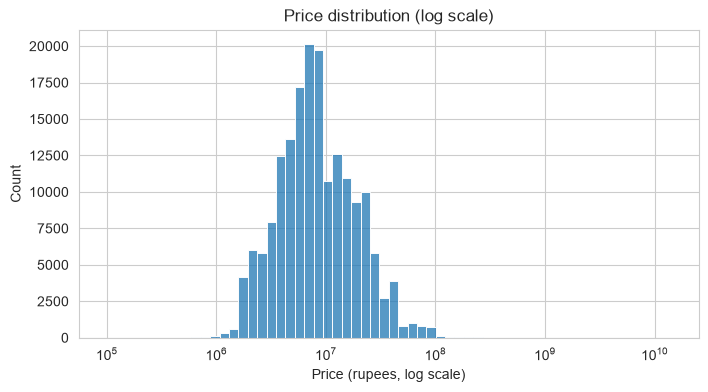

In [14]:
# Plot 1 - Target price distribution (heavily right-skewed, so use a log scale)
plt.figure(figsize=(8, 4))
sns.histplot(df["price_clean"], log_scale=True, bins=60)
plt.title("Price distribution (log scale)")
plt.xlabel("Price (rupees, log scale)")
plt.show()

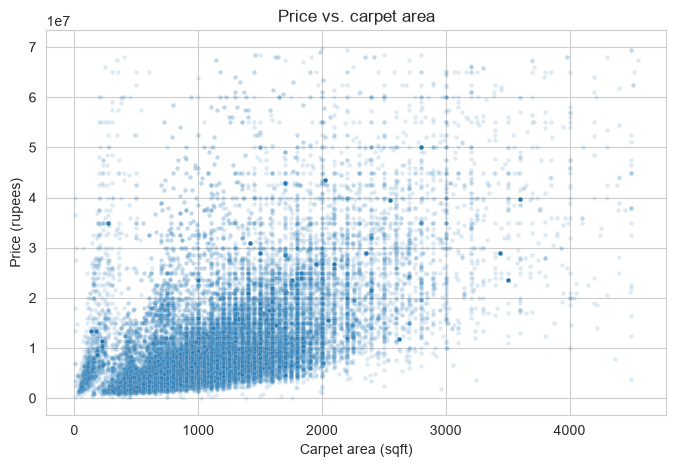

In [16]:
# Plot 2 - Price vs. carpet area
plot_df = df.dropna(subset=["carpet_area_sqft"])
plot_df = plot_df[(plot_df["carpet_area_sqft"] < plot_df["carpet_area_sqft"].quantile(0.99)) &
                   (plot_df["price_clean"] < plot_df["price_clean"].quantile(0.99))]

plt.figure(figsize=(8, 5))
sns.scatterplot(data=plot_df, x="carpet_area_sqft", y="price_clean", alpha=0.15, s=10)
plt.title("Price vs. carpet area")
plt.xlabel("Carpet area (sqft)")
plt.ylabel("Price (rupees)")
plt.show()

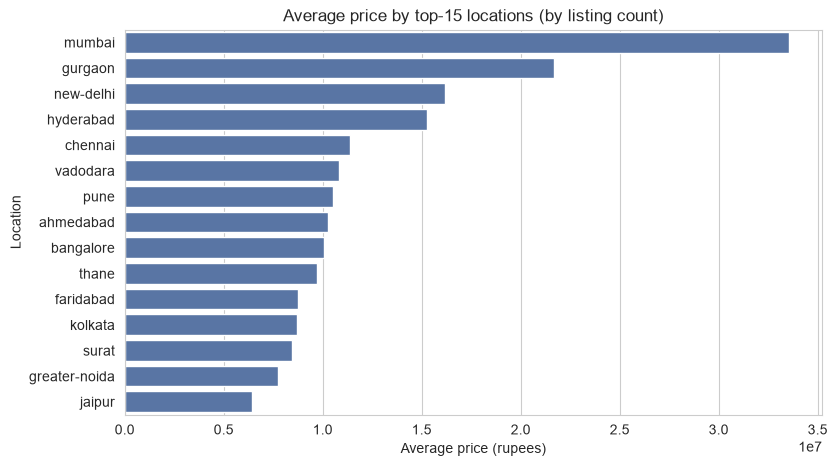

In [18]:
# Plot 3 - Average price by top-15 locations
top_locations = df["location"].value_counts().head(15).index
avg_by_location = (df[df["location"].isin(top_locations)]
                    .groupby("location")["price_clean"].mean()
                    .sort_values(ascending=False))

plt.figure(figsize=(9, 5))
sns.barplot(x=avg_by_location.values, y=avg_by_location.index, color="#4C72B0")
plt.title("Average price by top-15 locations (by listing count)")
plt.xlabel("Average price (rupees)")
plt.ylabel("Location")
plt.show()

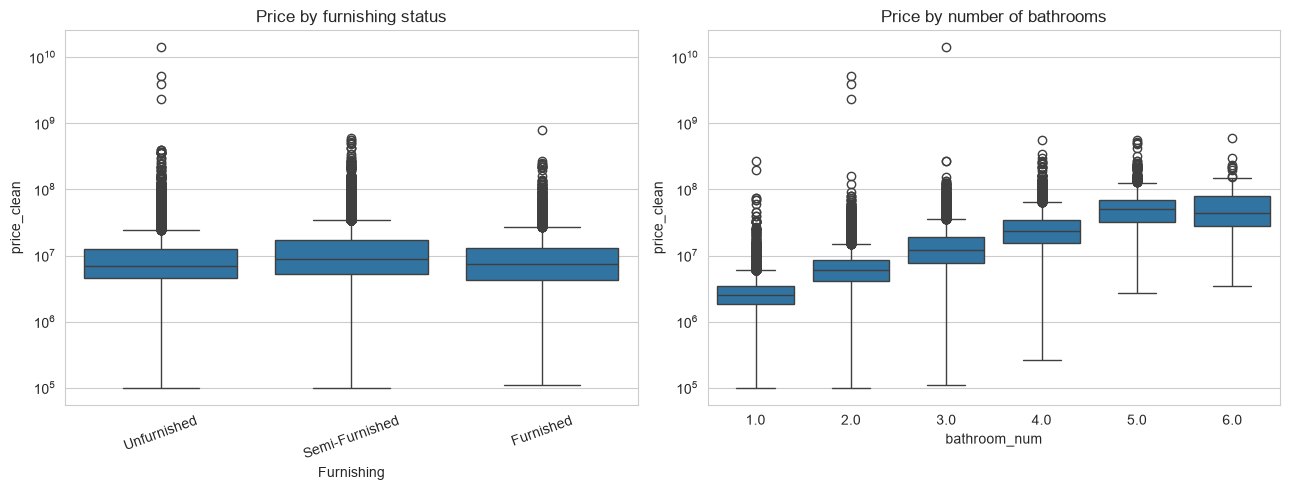

In [20]:
# Plot 4 - Price by furnishing status and by bathroom count
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=df, x="Furnishing", y="price_clean", ax=axes[0])
axes[0].set_yscale("log")
axes[0].set_title("Price by furnishing status")
axes[0].tick_params(axis="x", rotation=20)

bathroom_clean = pd.to_numeric(df["Bathroom"], errors="coerce")
plot_df2 = df.assign(bathroom_num=bathroom_clean)
plot_df2 = plot_df2[plot_df2["bathroom_num"].between(1, 6)]
sns.boxplot(data=plot_df2, x="bathroom_num", y="price_clean", ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("Price by number of bathrooms")

plt.tight_layout()
plt.show()

## 3. Cleaning & Feature Engineering


In [22]:
df = pd.read_csv("data/house_prices.csv")
print("Raw shape:", df.shape)

# 1) Price
df["price_clean"] = df["Amount(in rupees)"].apply(parse_amount)
df = df.dropna(subset=["price_clean"])
print("After price cleaning:", df.shape)

Raw shape: (187531, 21)
After price cleaning: (177847, 22)


In [23]:
# 2) Areas -> sqft (prefer Carpet Area, fall back to Super Area when missing)
df["carpet_area_sqft"] = df["Carpet Area"].apply(parse_area)
super_area_sqft = df["Super Area"].apply(parse_area)
df["carpet_area_sqft"] = df["carpet_area_sqft"].fillna(super_area_sqft)
df = df.dropna(subset=["carpet_area_sqft"])
df = df[df["carpet_area_sqft"] > 0]
print("After area cleaning:", df.shape)

After area cleaning: (177757, 23)


In [24]:
# 3)  floor_num
def parse_floor(x):
    if not isinstance(x, str):
        return np.nan
    x = x.strip().lower()
    if "ground" in x:
        return 0
    if "basement" in x or "lower" in x:
        return -1
    first_token = x.split(" ")[0]
    try:
        return float(first_token)
    except ValueError:
        return np.nan

df["floor_num"] = df["Floor"].apply(parse_floor)
df["floor_num"].describe()

count    170832.000000
mean          4.499584
std           4.701610
min          -1.000000
25%           2.000000
50%           3.000000
75%           6.000000
max         200.000000
Name: floor_num, dtype: float64

In [26]:
# 4) Bathroom / Balcony / Car Parking -> numeric, impute with median (fall back to 0)
for col, new_col in [("Bathroom", "bathroom"), ("Balcony", "balcony"), ("Car Parking", "car_parking")]:
    numeric = pd.to_numeric(df[col], errors="coerce")
    median = numeric.median()
    fill_value = median if not np.isnan(median) else 0
    df[new_col] = numeric.fillna(fill_value)

df[["bathroom", "balcony", "car_parking"]].describe()

,bathroom,balcony,car_parking
count,177757.000000,177757.000000,177757.0
mean,2.446216,2.008911,0.0
std,0.850656,0.815621,0.0
min,1.000000,1.000000,0.0
25%,2.000000,1.000000,0.0
50%,2.000000,2.000000,0.0
75%,3.000000,2.000000,0.0
max,10.000000,10.000000,0.0


In [29]:
TOP_N_LOCATIONS = 50
top_locations = df["location"].value_counts().head(TOP_N_LOCATIONS).index
df["location_grouped"] = df["location"].where(df["location"].isin(top_locations), "other")
df["location_grouped"].value_counts().head(10)

location_grouped
new-delhi        24945
bangalore        23260
kolkata          21605
gurgaon          18845
ahmedabad        12612
hyderabad        11134
chennai          10158
jaipur            7862
greater-noida     4490
faridabad         3732
Name: count, dtype: int64

In [32]:
drop_cols = ["Index", "Title", "Description", "Dimensions"]
df = df.drop(columns=[c for c in drop_cols if c in df.columns])

for col in ["Furnishing", "Transaction", "Ownership", "facing"]:
    df[col] = df[col].fillna("Unknown")

df.shape

(177757, 24)

In [34]:
# 7) Remove outliers: drop listings with absurd price-per-sqft (below 1st / above 99th percentile)
df["price_per_sqft"] = df["price_clean"] / df["carpet_area_sqft"]
low, high = df["price_per_sqft"].quantile([0.01, 0.99])
df = df[df["price_per_sqft"].between(low, high)]
df = df.drop(columns=["price_per_sqft"])
print("Final cleaned shape:", df.shape)

Final cleaned shape: (174471, 24)


## 4. Build a Pipeline & Train


In [36]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

numeric_features = ["carpet_area_sqft", "floor_num", "bathroom", "balcony"]
categorical_features = ["location_grouped", "Furnishing", "Transaction", "Ownership", "facing"]

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]), numeric_features),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]), categorical_features),
])

X = df[numeric_features + categorical_features]
y = df["price_clean"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape

((139576, 9), (34895, 9))

In [37]:
# Baseline model
linreg_model = Pipeline([
    ("prep", preprocessor),
    ("reg", LinearRegression()),
])
linreg_model.fit(X_train, y_train)

rf_model = Pipeline([
    ("prep", preprocessor),
    ("reg", RandomForestRegressor(n_estimators=200, max_depth=14, random_state=42, n_jobs=-1)),
])
rf_model.fit(X_train, y_train)

print("Both models trained.")

Both models trained.


## 5. Evaluate

In [39]:
def evaluate(model, name):
    pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, pred)
    rmse = root_mean_squared_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    print(f"{name}")
    print(f"  MAE : {mae:,.0f}")
    print(f"  RMSE: {rmse:,.0f}")
    print(f"  R^2 : {r2:.4f}")
    return {"model": name, "MAE": mae, "RMSE": rmse, "R2": r2}

results = []
results.append(evaluate(linreg_model, "Linear Regression"))
results.append(evaluate(rf_model, "Random Forest"))
results_df = pd.DataFrame(results).set_index("model")
results_df

Linear Regression
  MAE : 4,528,923
  RMSE: 8,393,175
  R^2 : 0.6227
Random Forest
  MAE : 1,351,110
  RMSE: 5,367,105
  R^2 : 0.8457


,MAE,RMSE,R2
model,,,
Linear Regression,4.528923e+06,8.393175e+06,0.622736
Random Forest,1.351110e+06,5.367105e+06,0.845733


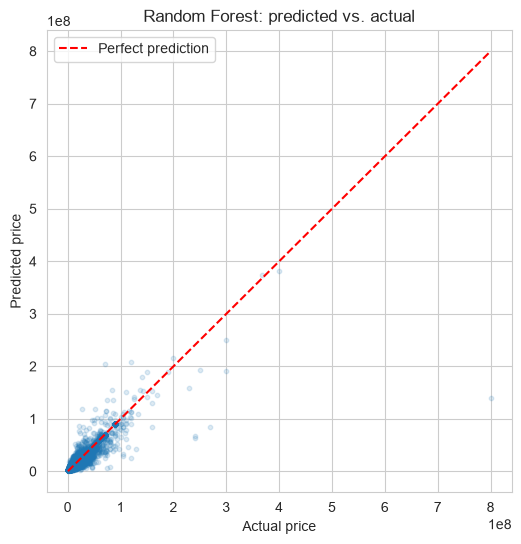

In [41]:
# Predicted vs. actual scatter plot for the Random Forest model
pred_rf = rf_model.predict(X_test)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, pred_rf, alpha=0.15, s=10)
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, color="red", linestyle="--", label="Perfect prediction")
plt.xlabel("Actual price")
plt.ylabel("Predicted price")
plt.title("Random Forest: predicted vs. actual")
plt.legend()
plt.show()

**Model comparison & winner:** the Random Forest clearly beats the Linear Regression
baseline on every metric (lower MAE/RMSE, higher R²), because price depends on non-linear
interactions between location, area and amenities that a linear model can't capture. We pick
the **Random Forest** as the final model.

In [42]:
# Bonus:
from sklearn.base import clone

cv_estimator = clone(rf_model)
cv_estimator.set_params(reg__n_estimators=60)
cv_scores = cross_val_score(cv_estimator, X, y, cv=5, scoring="neg_mean_absolute_error", n_jobs=1)
print("5-fold CV MAE:", (-cv_scores).round(0))
print("Mean CV MAE  :", (-cv_scores).mean().round(0))

5-fold CV MAE: [1835325. 7675688. 2322620. 6899215. 3690767.]
Mean CV MAE  : 4484723.0


## 6. Export the Model

In [44]:
import os
import joblib

FINAL_MODEL = rf_model  


joblib.dump(FINAL_MODEL, "house_price.pkl", compress=6)
print("Saved house_price.pkl (%.1f MB)" % (os.path.getsize("house_price.pkl") / 1e6))

Saved house_price.pkl (17.4 MB)


In [46]:
# Sanity check: reload and predict on one sample
loaded = joblib.load("house_price.pkl")
sample = X_test.iloc[[0]]
print("Reloaded prediction:", loaded.predict(sample))
print("Actual price       :", y_test.iloc[0])

Reloaded prediction: [6987515.74469322]
Actual price       : 7000000.0


In [47]:
import json

json.dump(
    sorted(df["location_grouped"].unique().tolist()),
    open("locations.json", "w"),
    ensure_ascii=False,
)
print("Saved locations.json")

Saved locations.json


In [49]:
import sklearn
print("scikit-learn version:", sklearn.__version__)
print("Pin this exact version in backend/requirements.txt")

scikit-learn version: 1.9.0
Pin this exact version in backend/requirements.txt
